# Week 1: Dataset Loading and Exploratory Data Analysis

## Project: Sentiment Classification of Tweets Using Deep Learning

In this notebook, I load and inspect the Sentiment140 dataset from Kaggle.  
The main goal of Week 1 is to understand the dataset structure, check class distribution, inspect text examples, and prepare the project for further preprocessing and modeling.

Dataset: Sentiment140 dataset with 1.6 million tweets  
Source: https://www.kaggle.com/datasets/kazanova/sentiment140  
Task type: Text classification  
Target classes: negative and positive

In [25]:
# Import main libraries for data loading and analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
import html

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Dataset Path

The dataset is stored locally in the folder named **д**.  
The dataset file name is:

`training.1600000.processed.noemoticon`

The code below checks several possible paths, because the notebook can be opened either from the project root folder or from the `notebooks/` folder.

In [26]:
from pathlib import Path

# Current folder where the notebook is running
CURRENT_DIR = Path.cwd()

# Dataset file name
DATASET_NAME = "training.1600000.processed.noemoticon"

# Possible dataset paths
possible_paths = [
    CURRENT_DIR / DATASET_NAME,
    CURRENT_DIR / f"{DATASET_NAME}.csv",
]

dataset_path = None

for path in possible_paths:
    if path.exists():
        dataset_path = path
        break

if dataset_path is None:
    print("Dataset file was not found.")
    print("Current notebook folder:")
    print(CURRENT_DIR)
    print("\nFiles in this folder:")
    for file in CURRENT_DIR.iterdir():
        print("-", file.name)
else:
    print("Dataset found:")
    print(dataset_path)

Dataset found:
C:\Users\SpaceX\д\training.1600000.processed.noemoticon.csv


## 2. Load the Dataset

The Sentiment140 dataset does not contain column names in the file.  
Therefore, I manually assign the official column names:

- target
- ids
- date
- flag
- user
- text

The file is loaded with `latin-1` encoding because this dataset may contain special characters.

In [27]:
import pandas as pd
import csv

columns = ["target", "ids", "date", "flag", "user", "text"]

df = pd.read_csv(
    dataset_path,
    encoding="latin-1",
    names=columns,
    engine="python",
    quotechar='"',
    on_bad_lines="skip"
)

df.head()

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


## 3. Basic Dataset Information

In this step, I check the dataset size, column names, data types, and missing values.  
This helps to understand whether the dataset was loaded correctly.

In [28]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 1600000
Number of columns: 6

Column names:
['target', 'ids', 'date', 'flag', 'user', 'text']

Data types:
target     int64
ids        int64
date      object
flag      object
user      object
text      object
dtype: object


In [29]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
target    0
ids       0
date      0
flag      0
user      0
text      0
dtype: int64


In [30]:
# General information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   ids     1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


## 4. Target Labels

In the Sentiment140 dataset, the target column contains sentiment labels.

For this project:

- `0` means negative sentiment
- `4` means positive sentiment

I convert label `4` into `1` to make the target binary:

- `0` = negative
- `1` = positive

In [31]:
# Check original target values

print("Original target values:")
print(df["target"].value_counts().sort_index())

Original target values:
target
0    800000
4    800000
Name: count, dtype: int64


In [32]:
# Convert original labels into binary labels

df["label"] = df["target"].map({
    0: 0,
    4: 1
})

df["sentiment"] = df["label"].map({
    0: "negative",
    1: "positive"
})

# Check converted labels
print("Converted label distribution:")
print(df["sentiment"].value_counts())

Converted label distribution:
sentiment
negative    800000
positive    800000
Name: count, dtype: int64


## 5. Class Distribution

Class distribution is important because it shows whether the dataset is balanced or imbalanced.  
A balanced dataset helps the model learn both classes more fairly.

In [33]:
# Count examples in each sentiment class

class_counts = df["sentiment"].value_counts()

print("Class distribution:")
print(class_counts)

print("\nClass distribution in percentage:")
print((class_counts / len(df) * 100).round(2))

Class distribution:
sentiment
negative    800000
positive    800000
Name: count, dtype: int64

Class distribution in percentage:
sentiment
negative    50.0
positive    50.0
Name: count, dtype: float64


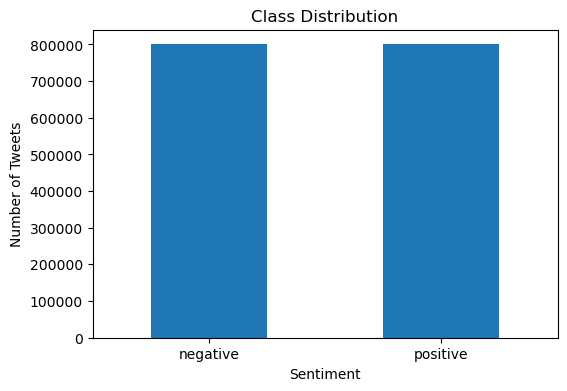

In [34]:
# Plot class distribution

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.show()

## 6. Example Tweets

In this step, I inspect several examples from each sentiment class.  
This helps to understand the text style, noise, and possible preprocessing needs.

In [35]:
# Show examples of negative tweets

negative_examples = df[df["sentiment"] == "negative"]["text"].sample(5, random_state=42)

print("Negative tweet examples:\n")
for i, text in enumerate(negative_examples, 1):
    print(f"{i}. {text}")

Negative tweet examples:

1. @xnausikaax oh no! where did u order from? that's horrible 
2. A great hard training weekend is over.  a couple days of rest and lets do it again!  Lots of computer time to put in now 
3. Right, off to work  Only 5 hours to go until I'm free xD
4. I am craving for japanese food 
5. Jean Michel Jarre concert tomorrow  gotta work 7-3 before though 


In [36]:
# Show examples of positive tweets

positive_examples = df[df["sentiment"] == "positive"]["text"].sample(5, random_state=42)

print("Positive tweet examples:\n")
for i, text in enumerate(positive_examples, 1):
    print(f"{i}. {text}")

Positive tweet examples:

1. Is lookin 4ward to a long weekend  really dont want to go to work 2day tho =[ x
2. #myweakness  Is music and i live to meet the people who make it 
3. figured out the Internet on my new iPod 
4. @hillsongunited can't wait to worship with you guys tonight. it'll be so much fun 
5. @sillybeggar Congrats James !! I'm sure the book is going to be a huge success 


## 7. Text Length Analysis

Tweet length is important for text classification.  
Very long or very short texts may affect model performance.

Here I calculate:

- number of characters in each tweet
- number of words in each tweet

In [37]:
# Add text length features

df["char_length"] = df["text"].astype(str).apply(len)
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

df[["text", "char_length", "word_count"]].head()

,text,char_length,word_count
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",115,19
1,is upset that he can't update his Facebook by ...,111,21
2,@Kenichan I dived many times for the ball. Man...,89,18
3,my whole body feels itchy and like its on fire,47,10
4,"@nationwideclass no, it's not behaving at all....",111,21


In [38]:
# Descriptive statistics for tweet length

print("Character length statistics:")
print(df["char_length"].describe())

print("\nWord count statistics:")
print(df["word_count"].describe())

Character length statistics:
count    1.600000e+06
mean     7.409011e+01
std      3.644114e+01
min      6.000000e+00
25%      4.400000e+01
50%      6.900000e+01
75%      1.040000e+02
max      3.740000e+02
Name: char_length, dtype: float64

Word count statistics:
count    1.600000e+06
mean     1.317615e+01
std      6.957978e+00
min      1.000000e+00
25%      7.000000e+00
50%      1.200000e+01
75%      1.900000e+01
max      6.400000e+01
Name: word_count, dtype: float64


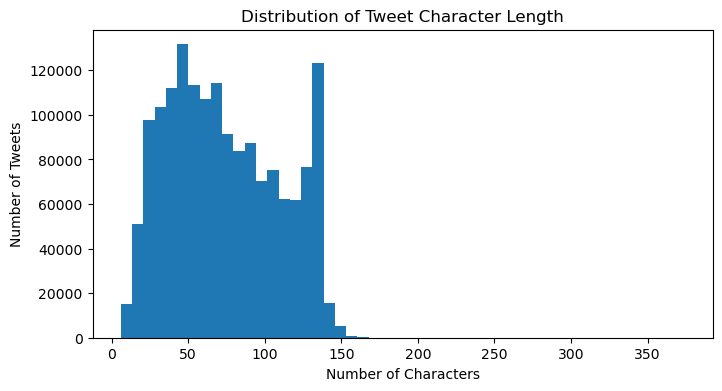

In [39]:
# Plot character length distribution

plt.figure(figsize=(8, 4))
plt.hist(df["char_length"], bins=50)
plt.title("Distribution of Tweet Character Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Tweets")
plt.show()

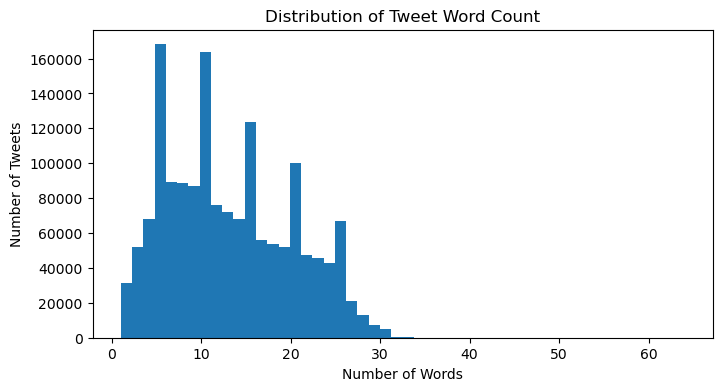

In [40]:
# Plot word count distribution

plt.figure(figsize=(8, 4))
plt.hist(df["word_count"], bins=50)
plt.title("Distribution of Tweet Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Number of Tweets")
plt.show()

## 8. Text Cleaning Preview

Tweets often contain noise such as links, usernames, hashtags, extra spaces, and special symbols.  
For Week 1, I create a simple cleaning function only for inspection.  
Full preprocessing will be completed in Week 2.

In [41]:
# Simple text cleaning function for preview

def clean_tweet_preview(text):
    text = str(text)
    
    # Convert HTML entities
    text = html.unescape(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # Replace usernames with a special token
    text = re.sub(r"@\w+", " user ", text)
    
    # Remove hashtag symbol but keep the word
    text = re.sub(r"#", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [42]:
# Compare original and cleaned text examples

sample_texts = df[["text", "sentiment"]].sample(10, random_state=42).copy()
sample_texts["clean_text_preview"] = sample_texts["text"].apply(clean_tweet_preview)

sample_texts

,text,sentiment,clean_text_preview
541200,@chrishasboobs AHHH I HOPE YOUR OK!!!,negative,user ahhh i hope your ok!!!
750,"@misstoriblack cool , i have no tweet apps fo...",negative,"user cool , i have no tweet apps for my razr 2"
766711,@TiannaChaos i know just family drama. its la...,negative,user i know just family drama. its lame.hey ne...
285055,School email won't open and I have geography ...,negative,school email won't open and i have geography s...
705995,upper airways problem,negative,upper airways problem
379611,Going to miss Pastor's sermon on Faith...,negative,going to miss pastor's sermon on faith...
1189018,on lunch....dj should come eat with me,positive,on lunch....dj should come eat with me
667030,@piginthepoke oh why are you feeling like that?,negative,user oh why are you feeling like that?
93541,gahh noo!peyton needs to live!this is horrible,negative,gahh noo!peyton needs to live!this is horrible
1097326,@mrstessyman thank you glad you like it! There...,positive,user thank you glad you like it! there is a pr...


## 9. Dataset Summary

This section creates a short summary table for Week 1 report.  
The summary includes dataset size, number of classes, class distribution, and average tweet length.

In [43]:
# Create summary dictionary

summary = {
    "dataset_name": "Sentiment140 dataset with 1.6 million tweets",
    "source": "Kaggle",
    "task_type": "Text classification",
    "number_of_rows": len(df),
    "number_of_columns": df.shape[1],
    "classes": ", ".join(df["sentiment"].dropna().unique()),
    "negative_count": int((df["sentiment"] == "negative").sum()),
    "positive_count": int((df["sentiment"] == "positive").sum()),
    "average_character_length": round(df["char_length"].mean(), 2),
    "average_word_count": round(df["word_count"].mean(), 2),
}

summary_df = pd.DataFrame([summary])
summary_df

,dataset_name,source,task_type,number_of_rows,number_of_columns,classes,negative_count,positive_count,average_character_length,average_word_count
0,Sentiment140 dataset with 1.6 million tweets,Kaggle,Text classification,1600000,10,"negative, positive",800000,800000,74.09,13.18


In [44]:
# Save summary to results folder

results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)

summary_path = results_dir / "week01_dataset_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Week 1 dataset summary saved to:")
print(summary_path)

Week 1 dataset summary saved to:
C:\Users\SpaceX\д\results\week01_dataset_summary.csv


## 10. Week 1 Conclusion

During Week 1, the dataset was successfully loaded and inspected.  
The Sentiment140 dataset contains tweet texts and sentiment labels.  
The target labels were converted into binary classes: negative and positive.

The dataset is large and suitable for deep learning text classification.  
The exploratory data analysis showed that tweets contain noisy text, including usernames, links, hashtags, and informal language.  
This means that text preprocessing will be an important part of Week 2.

Next steps:

- clean tweet texts;
- tokenize text;
- encode labels;
- split data into train, validation, and test sets;
- build a baseline model using TF-IDF and Logistic Regression.